In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import sys; sys.path.insert(0, '../..')
from feature_engineering import add_trend_features


## 1-day Horizon


In [30]:
df = pd.read_csv('../../data/dataset.csv', parse_dates=['Date']).set_index('Date').sort_index()
df = add_trend_features(df)
df.head(3)


,BAA10Y,DFF,DGS10,DGS2,CPIAUCSL,CPIAUCSL_days_since,PPIACO,PPIACO_days_since,PCEPI,PCEPI_days_since,...,BAA10Y_roll5_std,BAA10Y_roll21_std,BAA10Y_mom5,BAA10Y_mom21,yield_curve_slope,VIX_roll5_mean,VIX_roll21_mean,SP500_mom21,DFF_mom21,credit_tier_spread
Date,,,,,,,,,,,,,,,,,,,,,
1990-01-01,NaN,7.97,NaN,NaN,127.5,0.0,114.9,0.0,58.553,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-02,1.91,8.54,7.94,7.87,127.5,1.0,114.9,1.0,58.553,1.0,...,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,NaN,0.98
1990-01-03,1.87,8.37,7.99,7.94,127.5,2.0,114.9,2.0,58.553,2.0,...,NaN,NaN,NaN,NaN,0.05,NaN,NaN,NaN,NaN,0.96


In [31]:
# Forecast horizon (days ahead). Change this to forecast further out.
H = 1

# Supervised setup: features at time t predict the *direction* of BAA10Y at t+H
# relative to t. Target = np.sign(BAA10Y(t+H) - BAA10Y(t)) ∈ {-1, +1} —
# the same "actual_direction" the regressor evaluates against.
y_future = df['BAA10Y'].shift(-H)
y_now    = df['BAA10Y']
delta    = y_future - y_now
X_full   = df.drop(columns=['BAA10Y'])
X_full['BAA10Y_current'] = df['BAA10Y']  # current spread as explicit feature

# Drop rows where target, current spread, or any feature is NaN, and drop
# flat moves (delta == 0) so direction is always strictly +/-1.
# The trend features (rolling windows) introduce NaN at the series start.
mask = delta.notna() & (delta != 0) & y_now.notna() & X_full.notna().all(axis=1)
X = X_full.loc[mask]
y = np.sign(delta.loc[mask]).astype(int)   # {-1, +1} direction label
y_t = y_now.loc[mask]  # current spread, kept for the naive last-value baseline

print(f"Horizon H = {H} day(s)")
print(f"Samples: {len(y)}  ({y.index.min().date()} → {y.index.max().date()})")
print(f"Class balance: up = {(y == 1).mean():.2%}, down = {(y == -1).mean():.2%}")


Horizon H = 1 day(s)
Samples: 7352  (1990-03-05 → 2025-12-30)
Class balance: up = 48.63%, down = 51.37%


In [32]:
TRAIN_WINDOW_YEARS = 30
start_eval_year = 2000

folds = []
for year in range(start_eval_year, y.index.year.max() + 1):
    # Rolling 30-year window: use at most the last 30 years of training data.
    # Falls back to all available data when fewer than 30 years exist.
    train_start = max(X.index.min(), pd.Timestamp(f"{year - TRAIN_WINDOW_YEARS}-10-01"))
    train_end  = pd.Timestamp(f"{year}-09-30")
    test_start = pd.Timestamp(f"{year}-10-01")
    test_end   = pd.Timestamp(f"{year}-12-31")

    train_mask = (X.index >= train_start) & (X.index <= train_end)
    test_mask  = (X.index >= test_start) & (X.index <= test_end)

    if train_mask.sum() > 0 and test_mask.sum() > 0:
        folds.append({
            'year':     year,
            'X_train':  X.loc[train_mask],
            'y_train':  y.loc[train_mask],
            'X_test':   X.loc[test_mask],
            'y_test':   y.loc[test_mask],
            'y_t_test': y_t.loc[test_mask],
        })

print(f"Folds: {len(folds)}  ({folds[0]['year']} → {folds[-1]['year']})")
for f in folds[:3] + [folds[-1]]:
    print(f"  {f['year']}: train {f['X_train'].index.min().date()} → "
          f"{f['X_train'].index.max().date()} ({len(f['X_train'])} rows) | "
          f"test {f['X_test'].index.min().date()} → "
          f"{f['X_test'].index.max().date()} ({len(f['X_test'])} rows)")


Folds: 26  (2000 → 2025)
  2000: train 1990-03-05 → 2000-09-28 (2225 rows) | test 2000-10-01 → 2000-12-28 (53 rows)
  2001: train 1990-03-05 → 2001-09-30 (2433 rows) | test 2001-10-01 → 2001-12-30 (53 rows)
  2002: train 1990-03-05 → 2002-09-30 (2654 rows) | test 2002-10-01 → 2002-12-29 (51 rows)
  2025: train 1995-10-01 → 2025-09-30 (6101 rows) | test 2025-10-01 → 2025-12-30 (52 rows)


In [33]:
# Run OOB sweep on the first fold's training set to select n_estimators.
# Subsequent folds reuse this choice, keeping the sweep cost fixed.
X_oob = folds[0]['X_train']
y_oob = folds[0]['y_train']

n_grid = list(range(100, 1501, 100))

rf = RandomForestClassifier(
    n_estimators=n_grid[0],
    oob_score=True,
    bootstrap=True,
    warm_start=True,
    n_jobs=-1,
    random_state=42,
)

oob_error  = []
mean_depth = []
max_depth  = []
min_depth  = []

for n in n_grid:
    rf.set_params(n_estimators=n)
    rf.fit(X_oob, y_oob)
    err = 1.0 - rf.oob_score_  # OOB error rate (classification analogue of OOB RMSE)
    depths = np.array([t.get_depth() for t in rf.estimators_])
    oob_error.append(err)
    mean_depth.append(depths.mean())
    max_depth.append(depths.max())
    min_depth.append(depths.min())
    print(f"n_estimators={n:4d}  OOB error={err:.4f}  "
          f"depth mean={depths.mean():5.1f}  min={depths.min():3d}  max={depths.max():3d}")


n_estimators= 100  OOB error=0.4804  depth mean= 25.9  min= 19  max= 40
n_estimators= 200  OOB error=0.4706  depth mean= 26.2  min= 19  max= 40
n_estimators= 300  OOB error=0.4607  depth mean= 25.9  min= 19  max= 40
n_estimators= 400  OOB error=0.4701  depth mean= 25.9  min= 19  max= 40
n_estimators= 500  OOB error=0.4706  depth mean= 25.9  min= 19  max= 40
n_estimators= 600  OOB error=0.4701  depth mean= 25.9  min= 19  max= 40
n_estimators= 700  OOB error=0.4683  depth mean= 25.9  min= 19  max= 40
n_estimators= 800  OOB error=0.4683  depth mean= 25.9  min= 19  max= 40
n_estimators= 900  OOB error=0.4674  depth mean= 26.0  min= 19  max= 40
n_estimators=1000  OOB error=0.4670  depth mean= 26.0  min= 19  max= 40
n_estimators=1100  OOB error=0.4661  depth mean= 26.0  min= 19  max= 43
n_estimators=1200  OOB error=0.4643  depth mean= 26.1  min= 19  max= 43
n_estimators=1300  OOB error=0.4674  depth mean= 26.1  min= 19  max= 43
n_estimators=1400  OOB error=0.4661  depth mean= 26.1  min= 19  

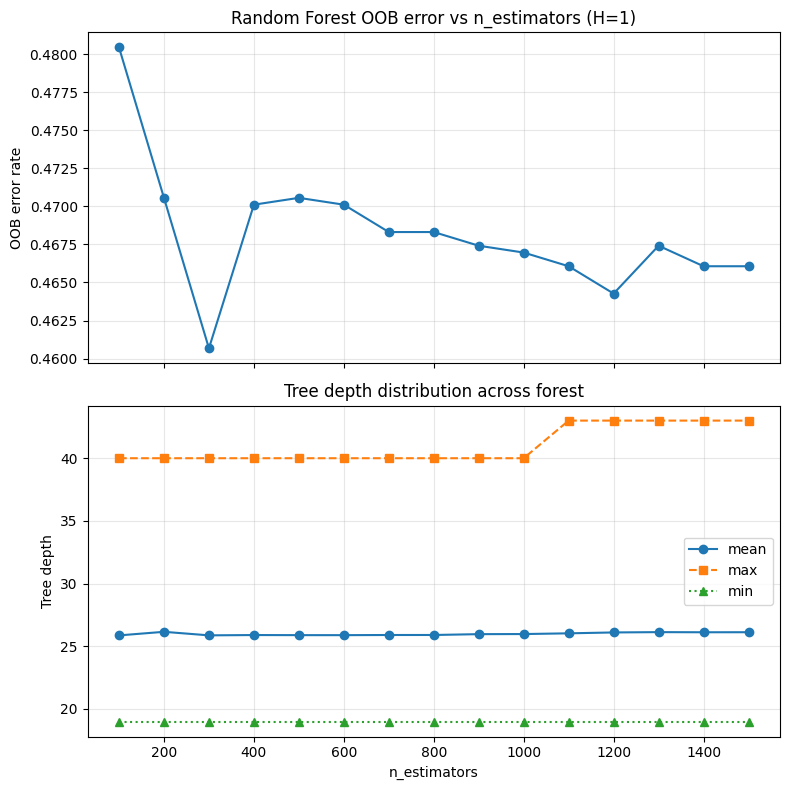

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].plot(n_grid, oob_error, marker='o')
axes[0].set_ylabel('OOB error rate')
axes[0].set_title(f'Random Forest OOB error vs n_estimators (H={H})')
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_grid, mean_depth, marker='o', label='mean')
axes[1].plot(n_grid, max_depth,  marker='s', label='max', linestyle='--')
axes[1].plot(n_grid, min_depth,  marker='^', label='min', linestyle=':')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Tree depth')
axes[1].set_title('Tree depth distribution across forest')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [35]:
best_n = n_grid[np.argmin(oob_error)]
print(f"Best n_estimators: {best_n}\n")

feature_names = folds[0]['X_train'].columns.tolist()
fold_results  = []
all_y_test    = []
all_y_pred    = []
all_y_curr    = []
all_importances = []

for fold in folds:
    rf_fold = RandomForestClassifier(
        n_estimators=best_n,
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    )
    rf_fold.fit(fold['X_train'], fold['y_train'])
    all_importances.append(rf_fold.feature_importances_)

    y_pred_fold = pd.Series(rf_fold.predict(fold['X_test']), index=fold['y_test'].index)
    y_true = fold['y_test']
    y_curr = fold['y_t_test']

    # Direction analysis is identical in form to the regressor: the only change
    # is that `pred_dir` is the classifier's direct output (not np.sign(y_pred - y_curr)).
    act_dir   = y_true.values
    pred_dir  = y_pred_fold.values
    naive_dir = np.zeros(len(y_true))   # SAME baseline as the regressor

    non_flat = act_dir != 0             # always True (flat moves dropped upstream)
    dir_acc       = (act_dir[non_flat] == pred_dir[non_flat]).mean() if non_flat.sum() > 0 else np.nan
    dir_acc_naive = (act_dir[non_flat] == naive_dir[non_flat]).mean() if non_flat.sum() > 0 else np.nan

    fold_results.append({
        'year': fold['year'], 'n_test': len(y_true),
        'dir_acc': dir_acc, 'dir_acc_naive': dir_acc_naive,
    })
    all_y_test.append(y_true)
    all_y_pred.append(y_pred_fold)
    all_y_curr.append(y_curr)
    print(f"{fold['year']}: DirAcc={dir_acc:.2%} (naive={dir_acc_naive:.2%})")

y_test_all = pd.concat(all_y_test)
y_pred_all = pd.concat(all_y_pred)
y_curr_all = pd.concat(all_y_curr)
results_df = pd.DataFrame(fold_results).set_index('year')

print(f"\n{'':8} {'DirAcc':>8} {'Naive':>8}")
print("-" * 28)
print(f"{'Mean':8} {results_df['dir_acc'].mean():>8.2%} "
      f"{results_df['dir_acc_naive'].mean():>8.2%}")


Best n_estimators: 300

2000: DirAcc=49.06% (naive=0.00%)
2001: DirAcc=62.26% (naive=0.00%)
2002: DirAcc=58.82% (naive=0.00%)
2003: DirAcc=44.90% (naive=0.00%)
2004: DirAcc=65.12% (naive=0.00%)
2005: DirAcc=67.57% (naive=0.00%)
2006: DirAcc=56.82% (naive=0.00%)
2007: DirAcc=42.59% (naive=0.00%)
2008: DirAcc=39.66% (naive=0.00%)
2009: DirAcc=48.15% (naive=0.00%)
2010: DirAcc=49.09% (naive=0.00%)
2011: DirAcc=60.00% (naive=0.00%)
2012: DirAcc=39.58% (naive=0.00%)
2013: DirAcc=31.82% (naive=0.00%)
2014: DirAcc=46.81% (naive=0.00%)
2015: DirAcc=58.18% (naive=0.00%)
2016: DirAcc=36.96% (naive=0.00%)
2017: DirAcc=57.45% (naive=0.00%)
2018: DirAcc=31.91% (naive=0.00%)
2019: DirAcc=66.00% (naive=0.00%)
2020: DirAcc=50.98% (naive=0.00%)
2021: DirAcc=46.51% (naive=0.00%)
2022: DirAcc=61.82% (naive=0.00%)
2023: DirAcc=56.14% (naive=0.00%)
2024: DirAcc=41.67% (naive=0.00%)
2025: DirAcc=48.08% (naive=0.00%)

           DirAcc    Naive
----------------------------
Mean       50.69%    0.00%


In [36]:
# Identical analysis to the regressor; `predicted_direction` is the classifier's
# direct output instead of np.sign(y_pred - y_curr), and y_test_all is already
# the direction label (+/-1).
actual_direction    = y_test_all.values
predicted_direction = y_pred_all.values
naive_direction     = np.zeros(len(y_test_all))

non_flat = actual_direction != 0
dir_acc_rf    = (actual_direction[non_flat] == predicted_direction[non_flat]).mean()
dir_acc_naive = (actual_direction[non_flat] == naive_direction[non_flat]).mean()

up_mask   = actual_direction[non_flat] == 1
down_mask = actual_direction[non_flat] == -1

print(f"Overall directional accuracy across all folds (excl. flat moves, n={non_flat.sum()}):")
print(f"  RF model : {dir_acc_rf:.2%}")
print(f"  Naive    : {dir_acc_naive:.2%}")
print(f"\nBreakdown by actual direction:")
print(f"  Actual UP   ({up_mask.sum():4d} days): RF correct {(predicted_direction[non_flat][up_mask] == 1).mean():.2%}")
print(f"  Actual DOWN ({down_mask.sum():4d} days): RF correct {(predicted_direction[non_flat][down_mask] == -1).mean():.2%}")


Overall directional accuracy across all folds (excl. flat moves, n=1296):
  RF model : 50.69%
  Naive    : 0.00%

Breakdown by actual direction:
  Actual UP   ( 586 days): RF correct 47.10%
  Actual DOWN ( 710 days): RF correct 53.66%


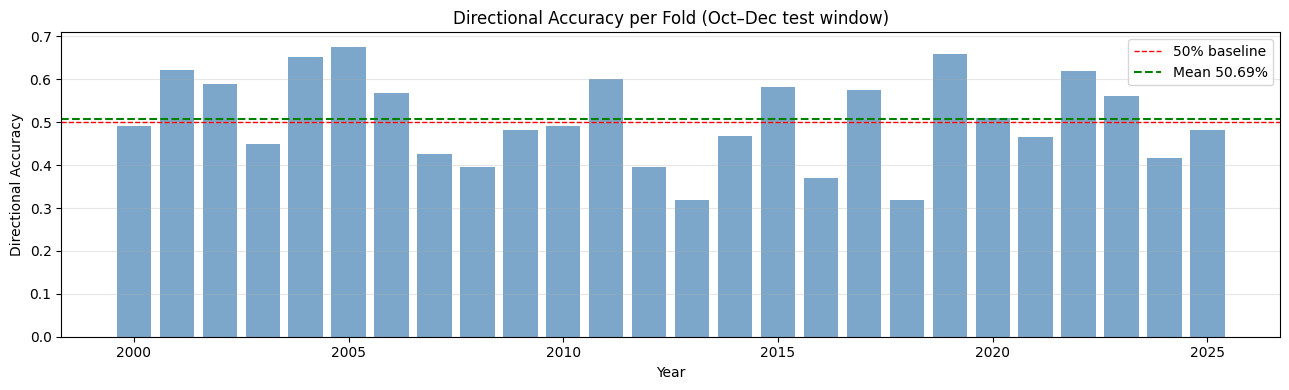

In [37]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(results_df.index, results_df['dir_acc'], color='steelblue', alpha=0.7)
ax.axhline(0.5, color='red',   lw=1,   linestyle='--', label='50% baseline')
ax.axhline(results_df['dir_acc'].mean(), color='green', lw=1.5, linestyle='--',
           label=f"Mean {results_df['dir_acc'].mean():.2%}")
ax.set_xlabel('Year')
ax.set_ylabel('Directional Accuracy')
ax.set_title('Directional Accuracy per Fold (Oct–Dec test window)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


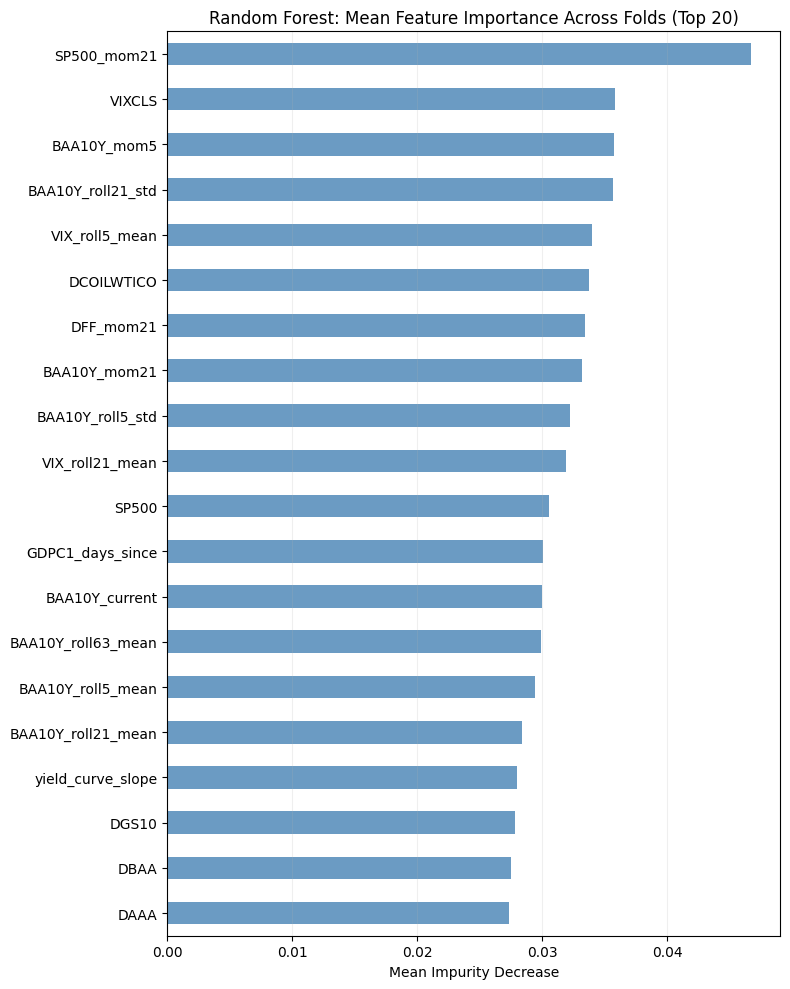

In [38]:
mean_imp = pd.Series(
    np.mean(all_importances, axis=0),
    index=feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
mean_imp.tail(20).plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Random Forest: Mean Feature Importance Across Folds (Top 20)')
ax.set_xlabel('Mean Impurity Decrease')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()


## 7-day Horizon


In [39]:
df = pd.read_csv('../../data/dataset.csv', parse_dates=['Date']).set_index('Date').sort_index()
df = add_trend_features(df)
df.head(3)


,BAA10Y,DFF,DGS10,DGS2,CPIAUCSL,CPIAUCSL_days_since,PPIACO,PPIACO_days_since,PCEPI,PCEPI_days_since,...,BAA10Y_roll5_std,BAA10Y_roll21_std,BAA10Y_mom5,BAA10Y_mom21,yield_curve_slope,VIX_roll5_mean,VIX_roll21_mean,SP500_mom21,DFF_mom21,credit_tier_spread
Date,,,,,,,,,,,,,,,,,,,,,
1990-01-01,NaN,7.97,NaN,NaN,127.5,0.0,114.9,0.0,58.553,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-02,1.91,8.54,7.94,7.87,127.5,1.0,114.9,1.0,58.553,1.0,...,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,NaN,0.98
1990-01-03,1.87,8.37,7.99,7.94,127.5,2.0,114.9,2.0,58.553,2.0,...,NaN,NaN,NaN,NaN,0.05,NaN,NaN,NaN,NaN,0.96


In [40]:
# Forecast horizon (days ahead). Change this to forecast further out.
H = 7

# Supervised setup: features at time t predict the *direction* of BAA10Y at t+H
# relative to t. Target = np.sign(BAA10Y(t+H) - BAA10Y(t)) ∈ {-1, +1} —
# the same "actual_direction" the regressor evaluates against.
y_future = df['BAA10Y'].shift(-H)
y_now    = df['BAA10Y']
delta    = y_future - y_now
X_full   = df.drop(columns=['BAA10Y'])
X_full['BAA10Y_current'] = df['BAA10Y']  # current spread as explicit feature

# Drop rows where target, current spread, or any feature is NaN, and drop
# flat moves (delta == 0) so direction is always strictly +/-1.
# The trend features (rolling windows) introduce NaN at the series start.
mask = delta.notna() & (delta != 0) & y_now.notna() & X_full.notna().all(axis=1)
X = X_full.loc[mask]
y = np.sign(delta.loc[mask]).astype(int)   # {-1, +1} direction label
y_t = y_now.loc[mask]  # current spread, kept for the naive last-value baseline

print(f"Horizon H = {H} day(s)")
print(f"Samples: {len(y)}  ({y.index.min().date()} → {y.index.max().date()})")
print(f"Class balance: up = {(y == 1).mean():.2%}, down = {(y == -1).mean():.2%}")


Horizon H = 7 day(s)
Samples: 12036  (1990-03-05 → 2025-12-25)
Class balance: up = 47.72%, down = 52.28%


In [41]:
TRAIN_WINDOW_YEARS = 30
start_eval_year = 2000

folds = []
for year in range(start_eval_year, y.index.year.max() + 1):
    # Rolling 30-year window: use at most the last 30 years of training data.
    # Falls back to all available data when fewer than 30 years exist.
    train_start = max(X.index.min(), pd.Timestamp(f"{year - TRAIN_WINDOW_YEARS}-10-01"))
    train_end  = pd.Timestamp(f"{year}-09-30")
    test_start = pd.Timestamp(f"{year}-10-01")
    test_end   = pd.Timestamp(f"{year}-12-31")

    train_mask = (X.index >= train_start) & (X.index <= train_end)
    test_mask  = (X.index >= test_start) & (X.index <= test_end)

    if train_mask.sum() > 0 and test_mask.sum() > 0:
        folds.append({
            'year':     year,
            'X_train':  X.loc[train_mask],
            'y_train':  y.loc[train_mask],
            'X_test':   X.loc[test_mask],
            'y_test':   y.loc[test_mask],
            'y_t_test': y_t.loc[test_mask],
        })

print(f"Folds: {len(folds)}  ({folds[0]['year']} → {folds[-1]['year']})")
for f in folds[:3] + [folds[-1]]:
    print(f"  {f['year']}: train {f['X_train'].index.min().date()} → "
          f"{f['X_train'].index.max().date()} ({len(f['X_train'])} rows) | "
          f"test {f['X_test'].index.min().date()} → "
          f"{f['X_test'].index.max().date()} ({len(f['X_test'])} rows)")


Folds: 26  (2000 → 2025)
  2000: train 1990-03-05 → 2000-09-30 (3540 rows) | test 2000-10-01 → 2000-12-31 (91 rows)
  2001: train 1990-03-05 → 2001-09-30 (3890 rows) | test 2001-10-01 → 2001-12-31 (87 rows)
  2002: train 1990-03-05 → 2002-09-30 (4231 rows) | test 2002-10-01 → 2002-12-31 (85 rows)
  2025: train 1995-10-01 → 2025-09-29 (10077 rows) | test 2025-10-01 → 2025-12-25 (80 rows)


In [42]:
# Run OOB sweep on the first fold's training set to select n_estimators.
# Subsequent folds reuse this choice, keeping the sweep cost fixed.
X_oob = folds[0]['X_train']
y_oob = folds[0]['y_train']

n_grid = list(range(100, 1501, 100))

rf = RandomForestClassifier(
    n_estimators=n_grid[0],
    oob_score=True,
    bootstrap=True,
    warm_start=True,
    n_jobs=-1,
    random_state=42,
)

oob_error  = []
mean_depth = []
max_depth  = []
min_depth  = []

for n in n_grid:
    rf.set_params(n_estimators=n)
    rf.fit(X_oob, y_oob)
    err = 1.0 - rf.oob_score_  # OOB error rate (classification analogue of OOB RMSE)
    depths = np.array([t.get_depth() for t in rf.estimators_])
    oob_error.append(err)
    mean_depth.append(depths.mean())
    max_depth.append(depths.max())
    min_depth.append(depths.min())
    print(f"n_estimators={n:4d}  OOB error={err:.4f}  "
          f"depth mean={depths.mean():5.1f}  min={depths.min():3d}  max={depths.max():3d}")


n_estimators= 100  OOB error=0.1017  depth mean= 23.1  min= 18  max= 31
n_estimators= 200  OOB error=0.0989  depth mean= 23.1  min= 18  max= 32
n_estimators= 300  OOB error=0.0977  depth mean= 23.2  min= 18  max= 33
n_estimators= 400  OOB error=0.0992  depth mean= 23.1  min= 18  max= 33
n_estimators= 500  OOB error=0.0949  depth mean= 23.2  min= 18  max= 34
n_estimators= 600  OOB error=0.0955  depth mean= 23.2  min= 18  max= 34
n_estimators= 700  OOB error=0.0955  depth mean= 23.3  min= 17  max= 34
n_estimators= 800  OOB error=0.0938  depth mean= 23.3  min= 17  max= 34
n_estimators= 900  OOB error=0.0938  depth mean= 23.3  min= 17  max= 34
n_estimators=1000  OOB error=0.0941  depth mean= 23.2  min= 17  max= 34
n_estimators=1100  OOB error=0.0935  depth mean= 23.2  min= 17  max= 34
n_estimators=1200  OOB error=0.0938  depth mean= 23.2  min= 17  max= 34
n_estimators=1300  OOB error=0.0935  depth mean= 23.2  min= 17  max= 37
n_estimators=1400  OOB error=0.0935  depth mean= 23.2  min= 17  

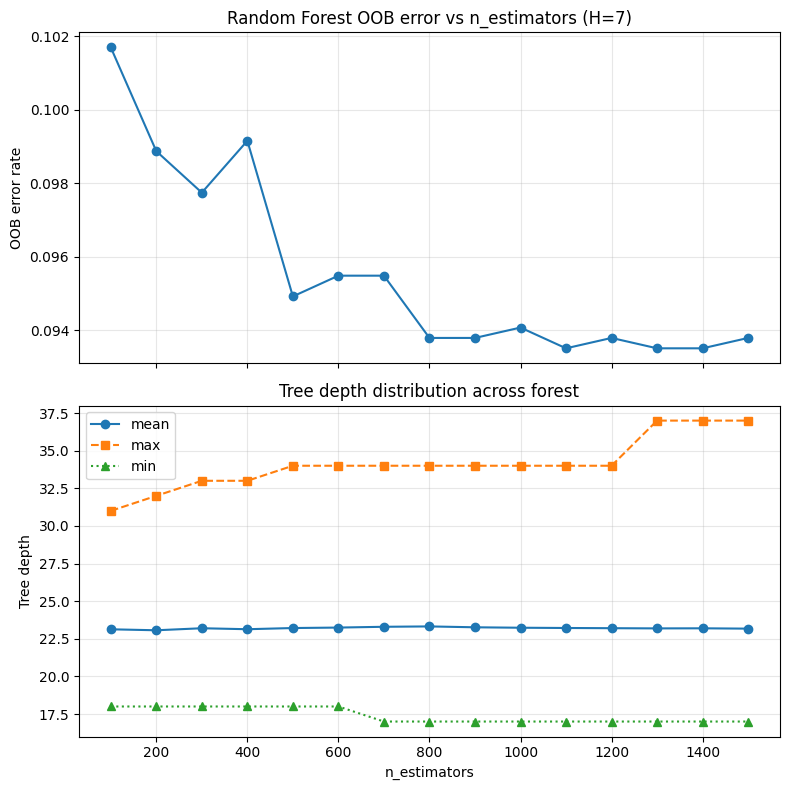

In [43]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].plot(n_grid, oob_error, marker='o')
axes[0].set_ylabel('OOB error rate')
axes[0].set_title(f'Random Forest OOB error vs n_estimators (H={H})')
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_grid, mean_depth, marker='o', label='mean')
axes[1].plot(n_grid, max_depth,  marker='s', label='max', linestyle='--')
axes[1].plot(n_grid, min_depth,  marker='^', label='min', linestyle=':')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Tree depth')
axes[1].set_title('Tree depth distribution across forest')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [44]:
best_n = n_grid[np.argmin(oob_error)]
print(f"Best n_estimators: {best_n}\n")

feature_names = folds[0]['X_train'].columns.tolist()
fold_results  = []
all_y_test    = []
all_y_pred    = []
all_y_curr    = []
all_importances = []

for fold in folds:
    rf_fold = RandomForestClassifier(
        n_estimators=best_n,
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    )
    rf_fold.fit(fold['X_train'], fold['y_train'])
    all_importances.append(rf_fold.feature_importances_)

    y_pred_fold = pd.Series(rf_fold.predict(fold['X_test']), index=fold['y_test'].index)
    y_true = fold['y_test']
    y_curr = fold['y_t_test']

    # Direction analysis is identical in form to the regressor: the only change
    # is that `pred_dir` is the classifier's direct output (not np.sign(y_pred - y_curr)).
    act_dir   = y_true.values
    pred_dir  = y_pred_fold.values
    naive_dir = np.zeros(len(y_true))   # SAME baseline as the regressor

    non_flat = act_dir != 0             # always True (flat moves dropped upstream)
    dir_acc       = (act_dir[non_flat] == pred_dir[non_flat]).mean() if non_flat.sum() > 0 else np.nan
    dir_acc_naive = (act_dir[non_flat] == naive_dir[non_flat]).mean() if non_flat.sum() > 0 else np.nan

    fold_results.append({
        'year': fold['year'], 'n_test': len(y_true),
        'dir_acc': dir_acc, 'dir_acc_naive': dir_acc_naive,
    })
    all_y_test.append(y_true)
    all_y_pred.append(y_pred_fold)
    all_y_curr.append(y_curr)
    print(f"{fold['year']}: DirAcc={dir_acc:.2%} (naive={dir_acc_naive:.2%})")

y_test_all = pd.concat(all_y_test)
y_pred_all = pd.concat(all_y_pred)
y_curr_all = pd.concat(all_y_curr)
results_df = pd.DataFrame(fold_results).set_index('year')

print(f"\n{'':8} {'DirAcc':>8} {'Naive':>8}")
print("-" * 28)
print(f"{'Mean':8} {results_df['dir_acc'].mean():>8.2%} "
      f"{results_df['dir_acc_naive'].mean():>8.2%}")


Best n_estimators: 1100

2000: DirAcc=31.87% (naive=0.00%)
2001: DirAcc=66.67% (naive=0.00%)
2002: DirAcc=40.00% (naive=0.00%)
2003: DirAcc=50.62% (naive=0.00%)
2004: DirAcc=65.79% (naive=0.00%)
2005: DirAcc=47.62% (naive=0.00%)
2006: DirAcc=60.71% (naive=0.00%)
2007: DirAcc=29.67% (naive=0.00%)
2008: DirAcc=42.39% (naive=0.00%)
2009: DirAcc=53.75% (naive=0.00%)
2010: DirAcc=26.37% (naive=0.00%)
2011: DirAcc=64.71% (naive=0.00%)
2012: DirAcc=55.56% (naive=0.00%)
2013: DirAcc=18.60% (naive=0.00%)
2014: DirAcc=52.22% (naive=0.00%)
2015: DirAcc=59.09% (naive=0.00%)
2016: DirAcc=58.54% (naive=0.00%)
2017: DirAcc=78.75% (naive=0.00%)
2018: DirAcc=16.47% (naive=0.00%)
2019: DirAcc=50.62% (naive=0.00%)
2020: DirAcc=40.48% (naive=0.00%)
2021: DirAcc=37.36% (naive=0.00%)
2022: DirAcc=52.81% (naive=0.00%)
2023: DirAcc=59.77% (naive=0.00%)
2024: DirAcc=47.50% (naive=0.00%)
2025: DirAcc=50.00% (naive=0.00%)

           DirAcc    Naive
----------------------------
Mean       48.38%    0.00%


In [45]:
# Identical analysis to the regressor; `predicted_direction` is the classifier's
# direct output instead of np.sign(y_pred - y_curr), and y_test_all is already
# the direction label (+/-1).
actual_direction    = y_test_all.values
predicted_direction = y_pred_all.values
naive_direction     = np.zeros(len(y_test_all))

non_flat = actual_direction != 0
dir_acc_rf    = (actual_direction[non_flat] == predicted_direction[non_flat]).mean()
dir_acc_naive = (actual_direction[non_flat] == naive_direction[non_flat]).mean()

up_mask   = actual_direction[non_flat] == 1
down_mask = actual_direction[non_flat] == -1

print(f"Overall directional accuracy across all folds (excl. flat moves, n={non_flat.sum()}):")
print(f"  RF model : {dir_acc_rf:.2%}")
print(f"  Naive    : {dir_acc_naive:.2%}")
print(f"\nBreakdown by actual direction:")
print(f"  Actual UP   ({up_mask.sum():4d} days): RF correct {(predicted_direction[non_flat][up_mask] == 1).mean():.2%}")
print(f"  Actual DOWN ({down_mask.sum():4d} days): RF correct {(predicted_direction[non_flat][down_mask] == -1).mean():.2%}")


Overall directional accuracy across all folds (excl. flat moves, n=2220):
  RF model : 48.06%
  Naive    : 0.00%

Breakdown by actual direction:
  Actual UP   ( 922 days): RF correct 51.74%
  Actual DOWN (1298 days): RF correct 45.45%


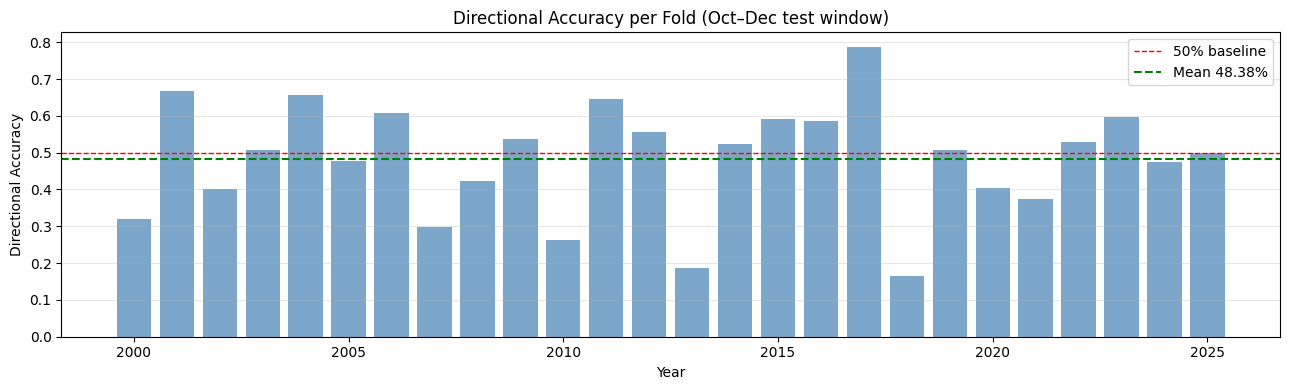

In [46]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(results_df.index, results_df['dir_acc'], color='steelblue', alpha=0.7)
ax.axhline(0.5, color='red',   lw=1,   linestyle='--', label='50% baseline')
ax.axhline(results_df['dir_acc'].mean(), color='green', lw=1.5, linestyle='--',
           label=f"Mean {results_df['dir_acc'].mean():.2%}")
ax.set_xlabel('Year')
ax.set_ylabel('Directional Accuracy')
ax.set_title('Directional Accuracy per Fold (Oct–Dec test window)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


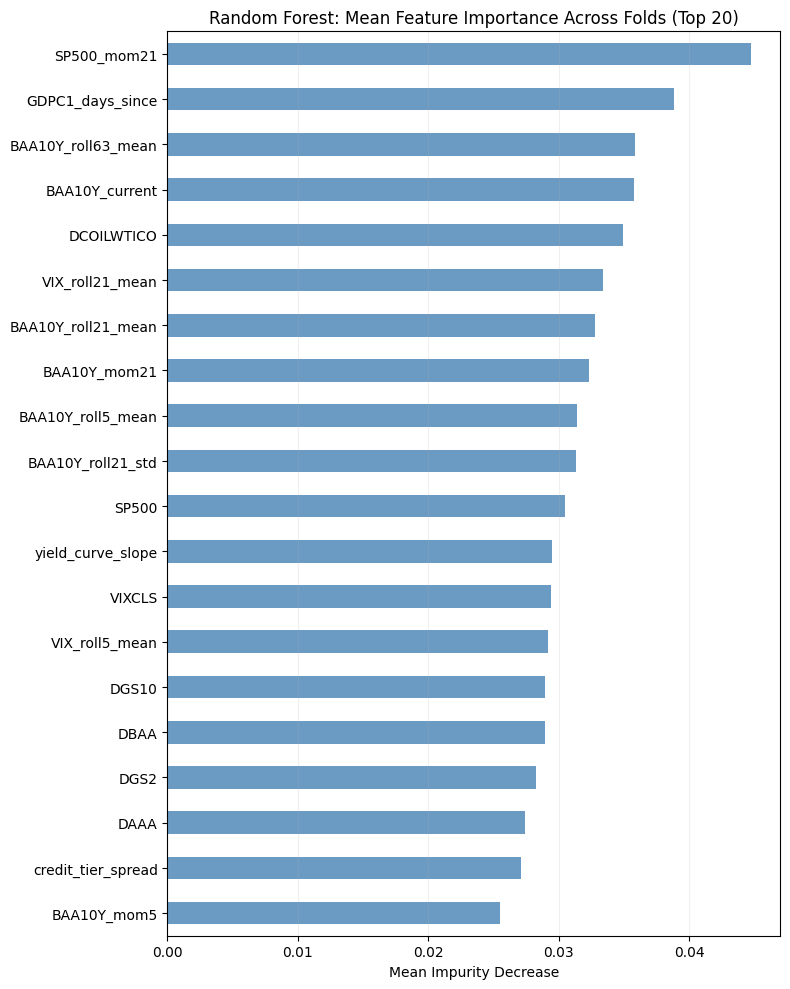

In [47]:
mean_imp = pd.Series(
    np.mean(all_importances, axis=0),
    index=feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
mean_imp.tail(20).plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Random Forest: Mean Feature Importance Across Folds (Top 20)')
ax.set_xlabel('Mean Impurity Decrease')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()


## 28-day Horizon


In [48]:
df = pd.read_csv('../../data/dataset.csv', parse_dates=['Date']).set_index('Date').sort_index()
df = add_trend_features(df)
df.head(3)


,BAA10Y,DFF,DGS10,DGS2,CPIAUCSL,CPIAUCSL_days_since,PPIACO,PPIACO_days_since,PCEPI,PCEPI_days_since,...,BAA10Y_roll5_std,BAA10Y_roll21_std,BAA10Y_mom5,BAA10Y_mom21,yield_curve_slope,VIX_roll5_mean,VIX_roll21_mean,SP500_mom21,DFF_mom21,credit_tier_spread
Date,,,,,,,,,,,,,,,,,,,,,
1990-01-01,NaN,7.97,NaN,NaN,127.5,0.0,114.9,0.0,58.553,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-02,1.91,8.54,7.94,7.87,127.5,1.0,114.9,1.0,58.553,1.0,...,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,NaN,0.98
1990-01-03,1.87,8.37,7.99,7.94,127.5,2.0,114.9,2.0,58.553,2.0,...,NaN,NaN,NaN,NaN,0.05,NaN,NaN,NaN,NaN,0.96


In [49]:
# Forecast horizon (days ahead). Change this to forecast further out.
H = 28

# Supervised setup: features at time t predict the *direction* of BAA10Y at t+H
# relative to t. Target = np.sign(BAA10Y(t+H) - BAA10Y(t)) ∈ {-1, +1} —
# the same "actual_direction" the regressor evaluates against.
y_future = df['BAA10Y'].shift(-H)
y_now    = df['BAA10Y']
delta    = y_future - y_now
X_full   = df.drop(columns=['BAA10Y'])
X_full['BAA10Y_current'] = df['BAA10Y']  # current spread as explicit feature

# Drop rows where target, current spread, or any feature is NaN, and drop
# flat moves (delta == 0) so direction is always strictly +/-1.
# The trend features (rolling windows) introduce NaN at the series start.
mask = delta.notna() & (delta != 0) & y_now.notna() & X_full.notna().all(axis=1)
X = X_full.loc[mask]
y = np.sign(delta.loc[mask]).astype(int)   # {-1, +1} direction label
y_t = y_now.loc[mask]  # current spread, kept for the naive last-value baseline

print(f"Horizon H = {H} day(s)")
print(f"Samples: {len(y)}  ({y.index.min().date()} → {y.index.max().date()})")
print(f"Class balance: up = {(y == 1).mean():.2%}, down = {(y == -1).mean():.2%}")


Horizon H = 28 day(s)
Samples: 12568  (1990-03-05 → 2025-12-04)
Class balance: up = 47.75%, down = 52.25%


In [50]:
TRAIN_WINDOW_YEARS = 30
start_eval_year = 2000

folds = []
for year in range(start_eval_year, y.index.year.max() + 1):
    # Rolling 30-year window: use at most the last 30 years of training data.
    # Falls back to all available data when fewer than 30 years exist.
    train_start = max(X.index.min(), pd.Timestamp(f"{year - TRAIN_WINDOW_YEARS}-10-01"))
    train_end  = pd.Timestamp(f"{year}-09-30")
    test_start = pd.Timestamp(f"{year}-10-01")
    test_end   = pd.Timestamp(f"{year}-12-31")

    train_mask = (X.index >= train_start) & (X.index <= train_end)
    test_mask  = (X.index >= test_start) & (X.index <= test_end)

    if train_mask.sum() > 0 and test_mask.sum() > 0:
        folds.append({
            'year':     year,
            'X_train':  X.loc[train_mask],
            'y_train':  y.loc[train_mask],
            'X_test':   X.loc[test_mask],
            'y_test':   y.loc[test_mask],
            'y_t_test': y_t.loc[test_mask],
        })

print(f"Folds: {len(folds)}  ({folds[0]['year']} → {folds[-1]['year']})")
for f in folds[:3] + [folds[-1]]:
    print(f"  {f['year']}: train {f['X_train'].index.min().date()} → "
          f"{f['X_train'].index.max().date()} ({len(f['X_train'])} rows) | "
          f"test {f['X_test'].index.min().date()} → "
          f"{f['X_test'].index.max().date()} ({len(f['X_test'])} rows)")


Folds: 26  (2000 → 2025)
  2000: train 1990-03-05 → 2000-09-30 (3722 rows) | test 2000-10-01 → 2000-12-31 (92 rows)
  2001: train 1990-03-05 → 2001-09-30 (4083 rows) | test 2001-10-01 → 2001-12-31 (91 rows)
  2002: train 1990-03-05 → 2002-09-30 (4445 rows) | test 2002-10-01 → 2002-12-31 (92 rows)
  2025: train 1995-10-01 → 2025-09-30 (10532 rows) | test 2025-10-01 → 2025-12-04 (62 rows)


In [51]:
# Run OOB sweep on the first fold's training set to select n_estimators.
# Subsequent folds reuse this choice, keeping the sweep cost fixed.
X_oob = folds[0]['X_train']
y_oob = folds[0]['y_train']

n_grid = list(range(100, 1501, 100))

rf = RandomForestClassifier(
    n_estimators=n_grid[0],
    oob_score=True,
    bootstrap=True,
    warm_start=True,
    n_jobs=-1,
    random_state=42,
)

oob_error  = []
mean_depth = []
max_depth  = []
min_depth  = []

for n in n_grid:
    rf.set_params(n_estimators=n)
    rf.fit(X_oob, y_oob)
    err = 1.0 - rf.oob_score_  # OOB error rate (classification analogue of OOB RMSE)
    depths = np.array([t.get_depth() for t in rf.estimators_])
    oob_error.append(err)
    mean_depth.append(depths.mean())
    max_depth.append(depths.max())
    min_depth.append(depths.min())
    print(f"n_estimators={n:4d}  OOB error={err:.4f}  "
          f"depth mean={depths.mean():5.1f}  min={depths.min():3d}  max={depths.max():3d}")


n_estimators= 100  OOB error=0.0476  depth mean= 19.7  min= 15  max= 26
n_estimators= 200  OOB error=0.0446  depth mean= 19.9  min= 15  max= 30
n_estimators= 300  OOB error=0.0457  depth mean= 19.9  min= 15  max= 30
n_estimators= 400  OOB error=0.0462  depth mean= 19.9  min= 15  max= 30
n_estimators= 500  OOB error=0.0467  depth mean= 19.9  min= 15  max= 30
n_estimators= 600  OOB error=0.0465  depth mean= 20.0  min= 15  max= 30
n_estimators= 700  OOB error=0.0462  depth mean= 20.0  min= 15  max= 30
n_estimators= 800  OOB error=0.0462  depth mean= 20.0  min= 15  max= 30
n_estimators= 900  OOB error=0.0459  depth mean= 20.0  min= 15  max= 30
n_estimators=1000  OOB error=0.0465  depth mean= 20.0  min= 15  max= 30
n_estimators=1100  OOB error=0.0462  depth mean= 20.0  min= 15  max= 30
n_estimators=1200  OOB error=0.0470  depth mean= 20.0  min= 15  max= 30
n_estimators=1300  OOB error=0.0465  depth mean= 20.0  min= 15  max= 30
n_estimators=1400  OOB error=0.0467  depth mean= 20.0  min= 15  

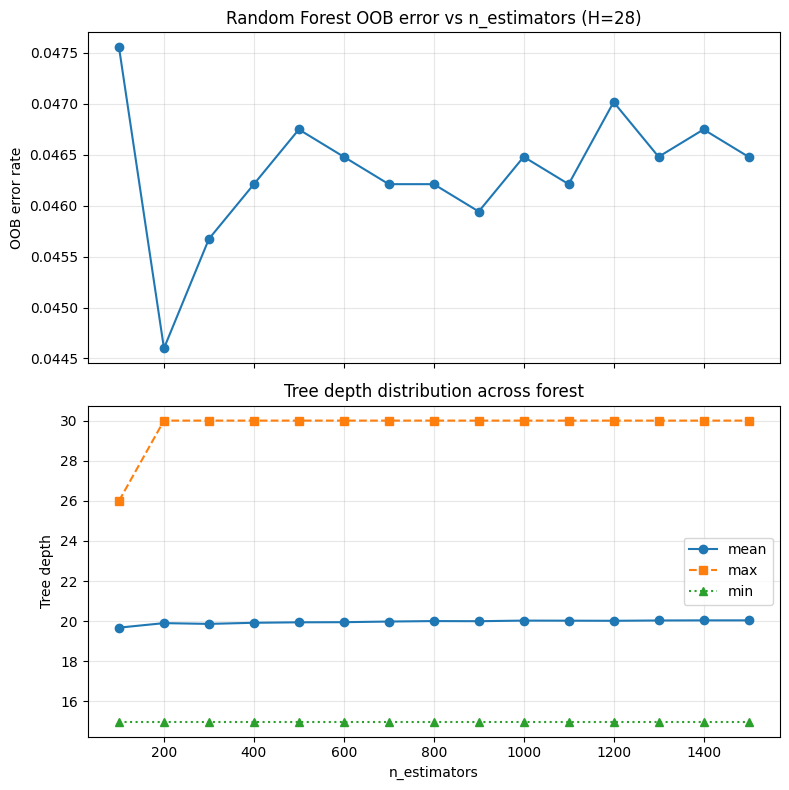

In [52]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].plot(n_grid, oob_error, marker='o')
axes[0].set_ylabel('OOB error rate')
axes[0].set_title(f'Random Forest OOB error vs n_estimators (H={H})')
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_grid, mean_depth, marker='o', label='mean')
axes[1].plot(n_grid, max_depth,  marker='s', label='max', linestyle='--')
axes[1].plot(n_grid, min_depth,  marker='^', label='min', linestyle=':')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Tree depth')
axes[1].set_title('Tree depth distribution across forest')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [53]:
best_n = n_grid[np.argmin(oob_error)]
print(f"Best n_estimators: {best_n}\n")

feature_names = folds[0]['X_train'].columns.tolist()
fold_results  = []
all_y_test    = []
all_y_pred    = []
all_y_curr    = []
all_importances = []

for fold in folds:
    rf_fold = RandomForestClassifier(
        n_estimators=best_n,
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    )
    rf_fold.fit(fold['X_train'], fold['y_train'])
    all_importances.append(rf_fold.feature_importances_)

    y_pred_fold = pd.Series(rf_fold.predict(fold['X_test']), index=fold['y_test'].index)
    y_true = fold['y_test']
    y_curr = fold['y_t_test']

    # Direction analysis is identical in form to the regressor: the only change
    # is that `pred_dir` is the classifier's direct output (not np.sign(y_pred - y_curr)).
    act_dir   = y_true.values
    pred_dir  = y_pred_fold.values
    naive_dir = np.zeros(len(y_true))   # SAME baseline as the regressor

    non_flat = act_dir != 0             # always True (flat moves dropped upstream)
    dir_acc       = (act_dir[non_flat] == pred_dir[non_flat]).mean() if non_flat.sum() > 0 else np.nan
    dir_acc_naive = (act_dir[non_flat] == naive_dir[non_flat]).mean() if non_flat.sum() > 0 else np.nan

    fold_results.append({
        'year': fold['year'], 'n_test': len(y_true),
        'dir_acc': dir_acc, 'dir_acc_naive': dir_acc_naive,
    })
    all_y_test.append(y_true)
    all_y_pred.append(y_pred_fold)
    all_y_curr.append(y_curr)
    print(f"{fold['year']}: DirAcc={dir_acc:.2%} (naive={dir_acc_naive:.2%})")

y_test_all = pd.concat(all_y_test)
y_pred_all = pd.concat(all_y_pred)
y_curr_all = pd.concat(all_y_curr)
results_df = pd.DataFrame(fold_results).set_index('year')

print(f"\n{'':8} {'DirAcc':>8} {'Naive':>8}")
print("-" * 28)
print(f"{'Mean':8} {results_df['dir_acc'].mean():>8.2%} "
      f"{results_df['dir_acc_naive'].mean():>8.2%}")


Best n_estimators: 200

2000: DirAcc=70.65% (naive=0.00%)
2001: DirAcc=93.41% (naive=0.00%)
2002: DirAcc=13.04% (naive=0.00%)
2003: DirAcc=25.88% (naive=0.00%)
2004: DirAcc=100.00% (naive=0.00%)
2005: DirAcc=40.00% (naive=0.00%)
2006: DirAcc=52.75% (naive=0.00%)
2007: DirAcc=8.99% (naive=0.00%)
2008: DirAcc=94.57% (naive=0.00%)
2009: DirAcc=32.18% (naive=0.00%)
2010: DirAcc=21.35% (naive=0.00%)
2011: DirAcc=66.67% (naive=0.00%)
2012: DirAcc=73.56% (naive=0.00%)
2013: DirAcc=47.78% (naive=0.00%)
2014: DirAcc=68.89% (naive=0.00%)
2015: DirAcc=83.13% (naive=0.00%)
2016: DirAcc=26.09% (naive=0.00%)
2017: DirAcc=79.55% (naive=0.00%)
2018: DirAcc=22.83% (naive=0.00%)
2019: DirAcc=28.09% (naive=0.00%)
2020: DirAcc=5.43% (naive=0.00%)
2021: DirAcc=43.96% (naive=0.00%)
2022: DirAcc=45.45% (naive=0.00%)
2023: DirAcc=32.95% (naive=0.00%)
2024: DirAcc=83.33% (naive=0.00%)
2025: DirAcc=48.39% (naive=0.00%)

           DirAcc    Naive
----------------------------
Mean       50.34%    0.00%


In [54]:
# Identical analysis to the regressor; `predicted_direction` is the classifier's
# direct output instead of np.sign(y_pred - y_curr), and y_test_all is already
# the direction label (+/-1).
actual_direction    = y_test_all.values
predicted_direction = y_pred_all.values
naive_direction     = np.zeros(len(y_test_all))

non_flat = actual_direction != 0
dir_acc_rf    = (actual_direction[non_flat] == predicted_direction[non_flat]).mean()
dir_acc_naive = (actual_direction[non_flat] == naive_direction[non_flat]).mean()

up_mask   = actual_direction[non_flat] == 1
down_mask = actual_direction[non_flat] == -1

print(f"Overall directional accuracy across all folds (excl. flat moves, n={non_flat.sum()}):")
print(f"  RF model : {dir_acc_rf:.2%}")
print(f"  Naive    : {dir_acc_naive:.2%}")
print(f"\nBreakdown by actual direction:")
print(f"  Actual UP   ({up_mask.sum():4d} days): RF correct {(predicted_direction[non_flat][up_mask] == 1).mean():.2%}")
print(f"  Actual DOWN ({down_mask.sum():4d} days): RF correct {(predicted_direction[non_flat][down_mask] == -1).mean():.2%}")


Overall directional accuracy across all folds (excl. flat moves, n=2288):
  RF model : 50.22%
  Naive    : 0.00%

Breakdown by actual direction:
  Actual UP   ( 829 days): RF correct 59.35%
  Actual DOWN (1459 days): RF correct 45.03%


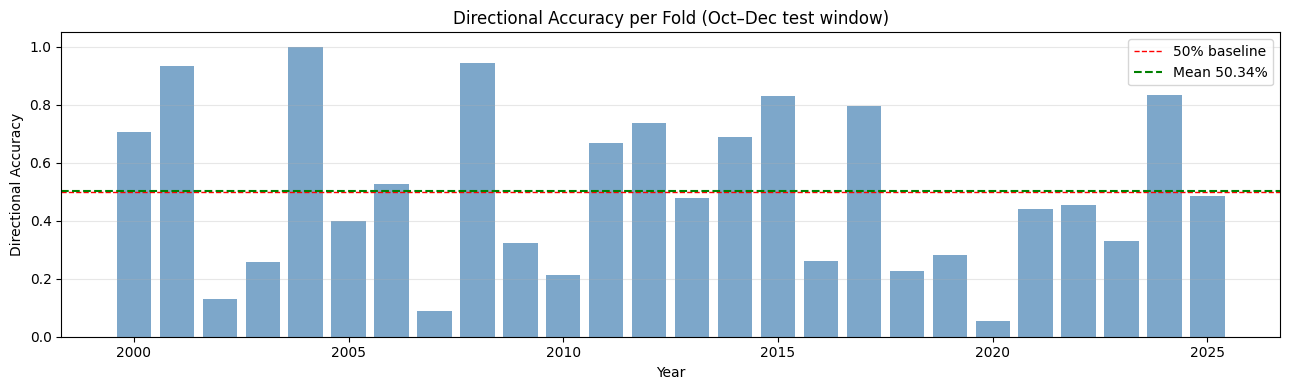

In [55]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(results_df.index, results_df['dir_acc'], color='steelblue', alpha=0.7)
ax.axhline(0.5, color='red',   lw=1,   linestyle='--', label='50% baseline')
ax.axhline(results_df['dir_acc'].mean(), color='green', lw=1.5, linestyle='--',
           label=f"Mean {results_df['dir_acc'].mean():.2%}")
ax.set_xlabel('Year')
ax.set_ylabel('Directional Accuracy')
ax.set_title('Directional Accuracy per Fold (Oct–Dec test window)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


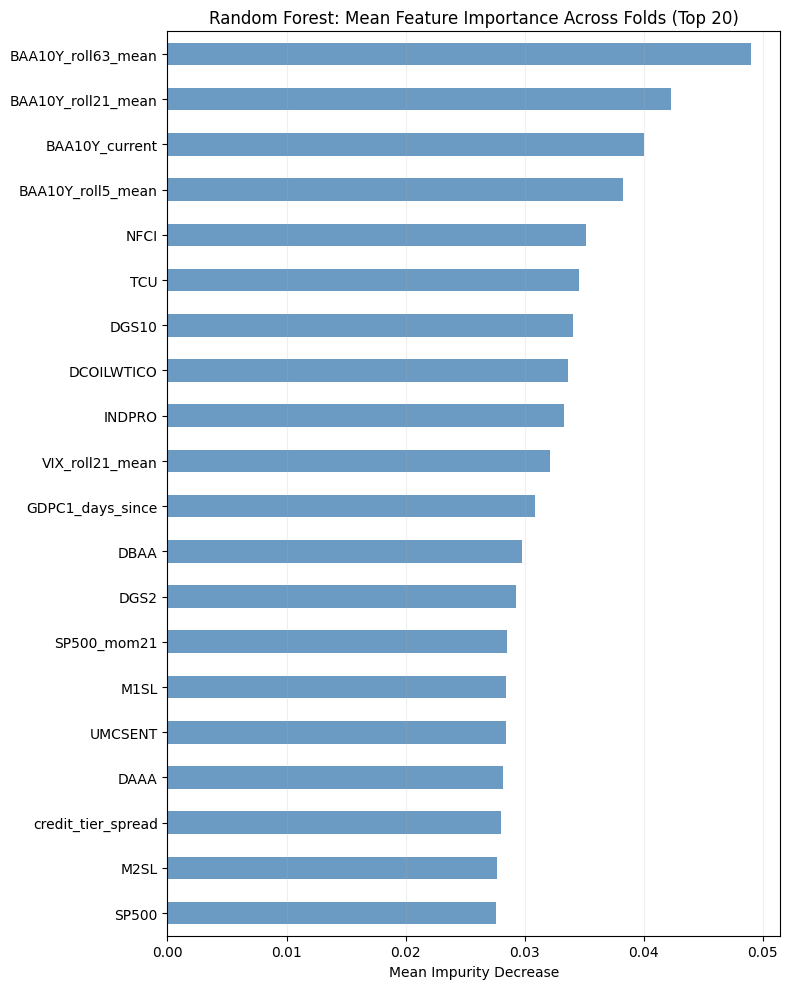

In [56]:
mean_imp = pd.Series(
    np.mean(all_importances, axis=0),
    index=feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
mean_imp.tail(20).plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Random Forest: Mean Feature Importance Across Folds (Top 20)')
ax.set_xlabel('Mean Impurity Decrease')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()
